# 04. Modelo Final e Conclusão

In [10]:
import sys
sys.path.append('./src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score, accuracy_score
import scipy.sparse as sp

from preprocessing import carregar_e_limpar, obter_ou_criar_split
from avaliacao import top_features_por_classe, cobertura_por_confianca, pr_auc_macro

import warnings
warnings.filterwarnings('ignore')

df = carregar_e_limpar('data/raw/dataset_ecommerce.csv')

le = LabelEncoder()
y = le.fit_transform(df['categoria'])

idx_train, idx_test = obter_ou_criar_split(df, y, caminho_split='data/processed/split.npz', test_size=0.2, random_state=42)
y_train, y_test = y[idx_train], y[idx_test]
texto_train = df['texto'].values[idx_train]
texto_test = df['texto'].values[idx_test]

## 1. Configuração escolhida

In [11]:
CONFIG_FINAL = {
    'representacao': 'TF-IDF',
    'dim': 5000,
    'modelo': 'Logistic Regression',
    'hiperparametros': {
        'C': 5.179554356516547,
        'class_weight': 'balanced',
        'max_iter': 2000,
        'random_state': 42,
    },
}
CONFIG_FINAL

{'representacao': 'TF-IDF',
 'dim': 5000,
 'modelo': 'Logistic Regression',
 'hiperparametros': {'C': 5.179554356516547,
  'class_weight': 'balanced',
  'max_iter': 2000,
  'random_state': 42}}

## 2. Treinar o modelo final

In [12]:
tfidf_final = TfidfVectorizer(max_features=5000, min_df=2)
X_train_final = tfidf_final.fit_transform(texto_train)
X_test_final = tfidf_final.transform(texto_test)

modelo_final = LogisticRegression(**CONFIG_FINAL['hiperparametros'])
modelo_final.fit(X_train_final, y_train)
print("Modelo final treinado.")

Modelo final treinado.


## 3. Avaliação no teste

In [13]:
y_pred = modelo_final.predict(X_test_final)
y_proba = modelo_final.predict_proba(X_test_final)

acc = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average='macro')
f1_weighted = f1_score(y_test, y_pred, average='weighted')
roc_auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')
pr_auc = pr_auc_macro(y_test, y_proba, le.classes_)

print(f"Accuracy:    {acc * 100:.1f}%")
print(f"F1 Macro:    {f1_macro * 100:.1f}%")
print(f"F1 Weighted: {f1_weighted * 100:.1f}%")
print(f"ROC-AUC:     {roc_auc * 100:.1f}%")
print(f"PR-AUC macro:{pr_auc['macro'] * 100:.1f}%")
print()
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy:    94.8%
F1 Macro:    94.8%
F1 Weighted: 94.8%
ROC-AUC:     99.1%
PR-AUC macro:97.8%

                      precision    recall  f1-score   support

               Books       0.94      0.93      0.94      1251
Clothing_Accessories       0.97      0.98      0.98      1135
         Electronics       0.93      0.93      0.93      1062
           Household       0.95      0.95      0.95      2113

            accuracy                           0.95      5561
           macro avg       0.95      0.95      0.95      5561
        weighted avg       0.95      0.95      0.95      5561



## 4. Matriz de confusão final

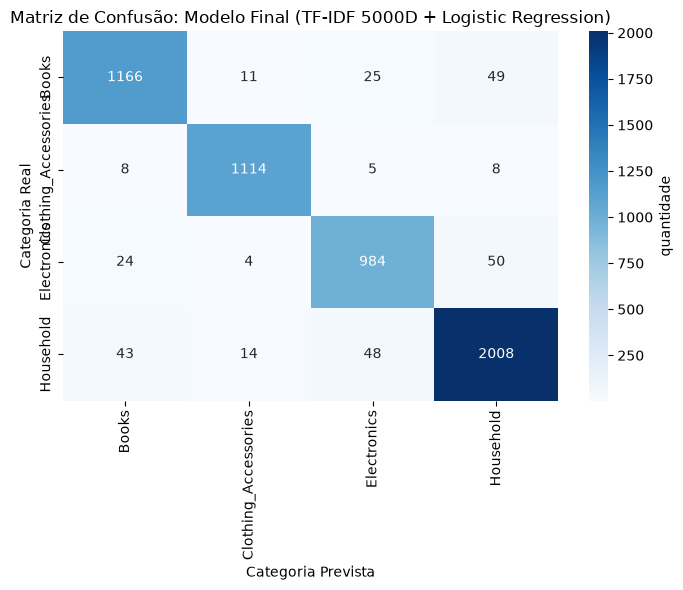

In [14]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_,
            cbar_kws={'label': 'quantidade'})
ax.set_title(f"Matriz de Confusão: Modelo Final ({CONFIG_FINAL['representacao']} {CONFIG_FINAL['dim']}D + {CONFIG_FINAL['modelo']})")
ax.set_xlabel('Categoria Prevista')
ax.set_ylabel('Categoria Real')
plt.tight_layout()
plt.savefig('figs/04_matriz_confusao_final.png', dpi=100)
plt.show()

## 5. Interpretabilidade: o que o modelo está usando para decidir

In [15]:
top_palavras = top_features_por_classe(modelo_final, tfidf_final, le.classes_, top_n=10)
for classe, dados_classe in top_palavras.items():
    palavras_str = ', '.join(p for p, _ in dados_classe['a_favor'])
    print(f"{classe:22s} -> {palavras_str}")


Books                  -> book, fishing, author, guide, game, action, museum, how, pool, training
Clothing_Accessories   -> women, men, sunglasses, boys, girls, cotton, bra, socks, unisex, jacket
Electronics            -> laptop, camera, lens, binoculars, cable, mount, tripod, calculator, hp, screen
Household              -> vacuum, door, bathrobe, chair, wallet, kitchen, bathroom, plastic, home, pillow


As palavras acima fazem sentido de negócio em todas as 4 categorias. Isso é evidência concreta a favor da hipótese de que o TF-IDF vence porque essas categorias têm vocabulário característico, não apenas uma suposição plausível.

## 6. Principais erros

In [16]:
erros = pd.DataFrame({
    'categoria_real': le.inverse_transform(y_test),
    'categoria_prevista': le.inverse_transform(y_pred),
})
apenas_erros = erros[erros['categoria_real'] != erros['categoria_prevista']]

pares = (apenas_erros.groupby(['categoria_real', 'categoria_prevista']).size()
         .reset_index(name='quantidade').sort_values('quantidade', ascending=False))
print(f"Taxa de erro geral: {len(apenas_erros) / len(erros) * 100:.1f}%")
display(pares.head(6))

Taxa de erro geral: 5.2%


,categoria_real,categoria_prevista,quantidade
8,Electronics,Household,50
2,Books,Household,49
11,Household,Electronics,48
9,Household,Books,43
1,Books,Electronics,25
6,Electronics,Books,24
